# Resultados de training — Optuna + mmBERT

Comparación de las 3 fases de tuning para **temas** y **carga**: trials Optuna, mejor modelo por fase y métricas en test.

Archivos en `data/tuning/*_study.json` y `*_best.json`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

import json
from matplotlib.ticker import MaxNLocator

TUNING = ROOT / "data" / "tuning"
TASKS = ["temas", "carga"]
PHASES = [1, 2, 3]


def study_path(task: str, phase: int) -> Path:
    suffix = "" if phase == 1 else f"_phase{phase}"
    return TUNING / f"{task}{suffix}_study.json"


def best_path(task: str, phase: int) -> Path:
    suffix = "" if phase == 1 else f"_phase{phase}"
    return TUNING / f"{task}{suffix}_best.json"


def load_studies() -> pd.DataFrame:
    rows = []
    for task in TASKS:
        for phase in PHASES:
            path = study_path(task, phase)
            if not path.exists():
                continue
            payload = json.loads(path.read_text(encoding="utf-8"))
            for trial in payload.get("trials", []):
                if trial.get("state") != "COMPLETE" or trial.get("value") is None:
                    continue
                row = {"task": task, "phase": phase, "trial": trial["number"], "val_f1": trial["value"]}
                row.update(trial.get("params", {}))
                rows.append(row)
    return pd.DataFrame(rows)


def load_bests() -> pd.DataFrame:
    rows = []
    for task in TASKS:
        for phase in PHASES:
            path = best_path(task, phase)
            if not path.exists():
                continue
            best = json.loads(path.read_text(encoding="utf-8"))
            test = best.get("final_test_metrics", {})
            rows.append(
                {
                    "task": task,
                    "phase": phase,
                    "trial": best.get("trial_number"),
                    "val_f1": best.get("val_f1_macro"),
                    "test_f1": test.get("test_f1_macro"),
                    "test_acc": test.get("test_accuracy"),
                    "model_dir": best.get("final_model_dir"),
                    **best.get("params", {}),
                }
            )
    return pd.DataFrame(rows)


trials = load_studies()
bests = load_bests()
print(f"Trials cargados: {len(trials)} | Mejores por fase: {len(bests)}")
bests


c:\Users\arihs\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Trials cargados: 120 | Mejores por fase: 6


,task,phase,trial,val_f1,test_f1,test_acc,model_dir,learning_rate,batch_size,num_epochs,warmup_ratio,weight_decay
0,temas,1,14,0.779919,0.742096,0.753470,C:\Users\arihs\Code\mlprod-obligatorio\models\...,0.000036,32,5,0.089099,0.075251
1,temas,2,17,0.770486,0.744776,0.755691,C:\Users\arihs\Code\mlprod-obligatorio\models\...,0.000039,48,6,0.072933,0.088393
2,temas,3,1,0.773695,0.732175,0.745697,C:\Users\arihs\Code\mlprod-obligatorio\models\...,0.000031,32,5,0.066437,0.067717
3,carga,1,10,0.811953,0.779883,0.795669,C:\Users\arihs\Code\mlprod-obligatorio\models\...,0.000026,16,3,0.051442,0.004607
4,carga,2,16,0.820213,0.774104,0.795669,C:\Users\arihs\Code\mlprod-obligatorio\models\...,0.000029,24,2,0.085884,0.019521
5,carga,3,2,0.812952,0.783117,0.803443,C:\Users\arihs\Code\mlprod-obligatorio\models\...,0.000021,16,3,0.063609,0.002960


c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future vers

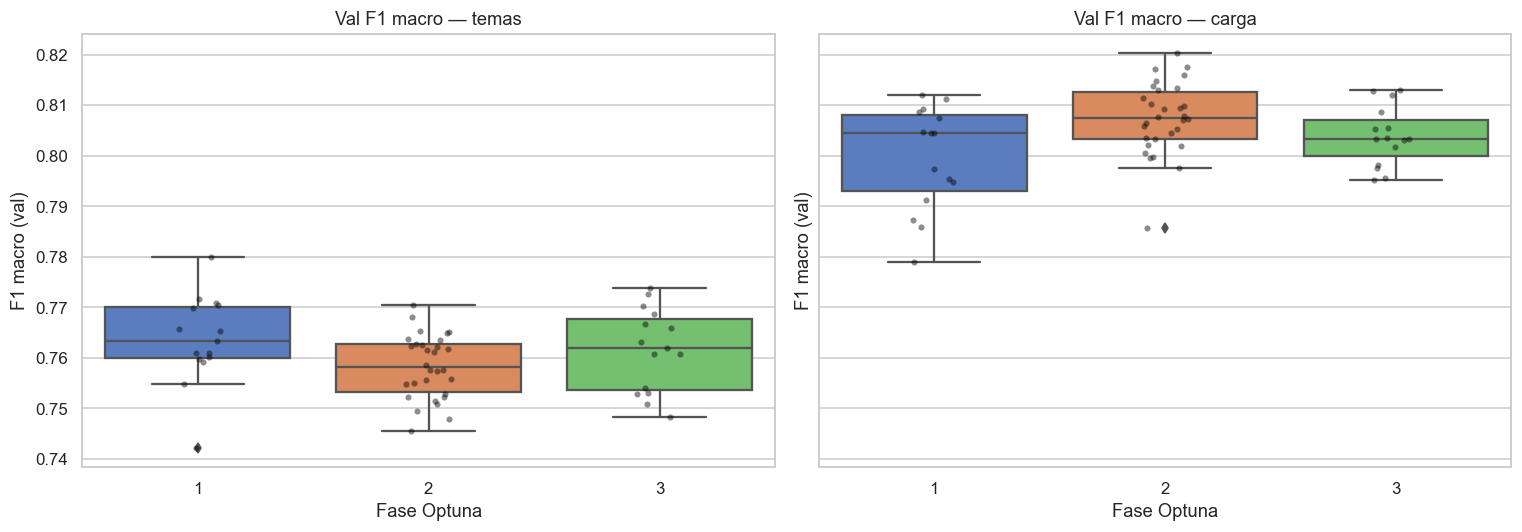

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASKS):
    subset = trials[trials["task"] == task]
    sns.boxplot(data=subset, x="phase", y="val_f1", ax=ax)
    sns.stripplot(data=subset, x="phase", y="val_f1", color="black", alpha=0.45, size=4, ax=ax)
    ax.set_title(f"Val F1 macro — {task}")
    ax.set_xlabel("Fase Optuna")
    ax.set_ylabel("F1 macro (val)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


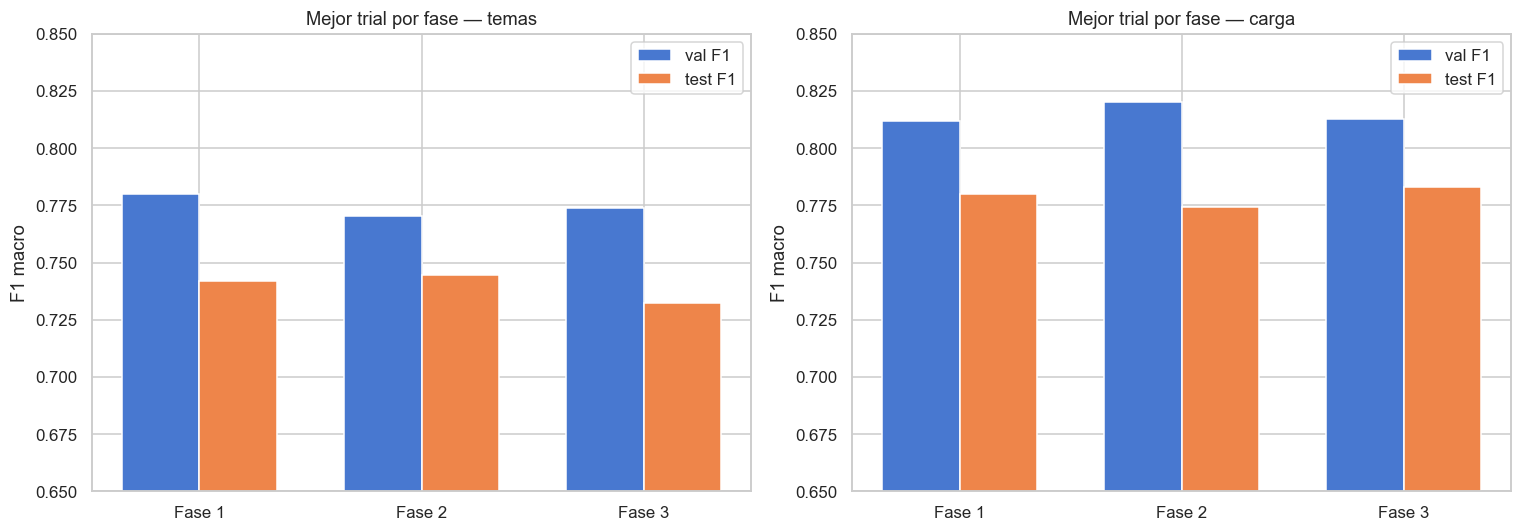

temas: fase 2 | test F1=0.745 | val F1=0.770 | trial 17
carga: fase 3 | test F1=0.783 | val F1=0.813 | trial 2


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    subset = bests[bests["task"] == task].sort_values("phase")
    x = subset["phase"].astype(str)
    width = 0.35
    idx = range(len(subset))
    ax.bar([i - width / 2 for i in idx], subset["val_f1"], width, label="val F1")
    ax.bar([i + width / 2 for i in idx], subset["test_f1"], width, label="test F1")
    ax.set_xticks(list(idx), [f"Fase {p}" for p in subset["phase"]])
    ax.set_ylim(0.65, 0.85)
    ax.set_title(f"Mejor trial por fase — {task}")
    ax.set_ylabel("F1 macro")
    ax.legend()

plt.tight_layout()
plt.show()

# Mejor en test por tarea
for task in TASKS:
    best_row = bests[bests["task"] == task].sort_values("test_f1", ascending=False).iloc[0]
    print(
        f"{task}: fase {int(best_row['phase'])} | "
        f"test F1={best_row['test_f1']:.3f} | val F1={best_row['val_f1']:.3f} | "
        f"trial {int(best_row['trial'])}"
    )


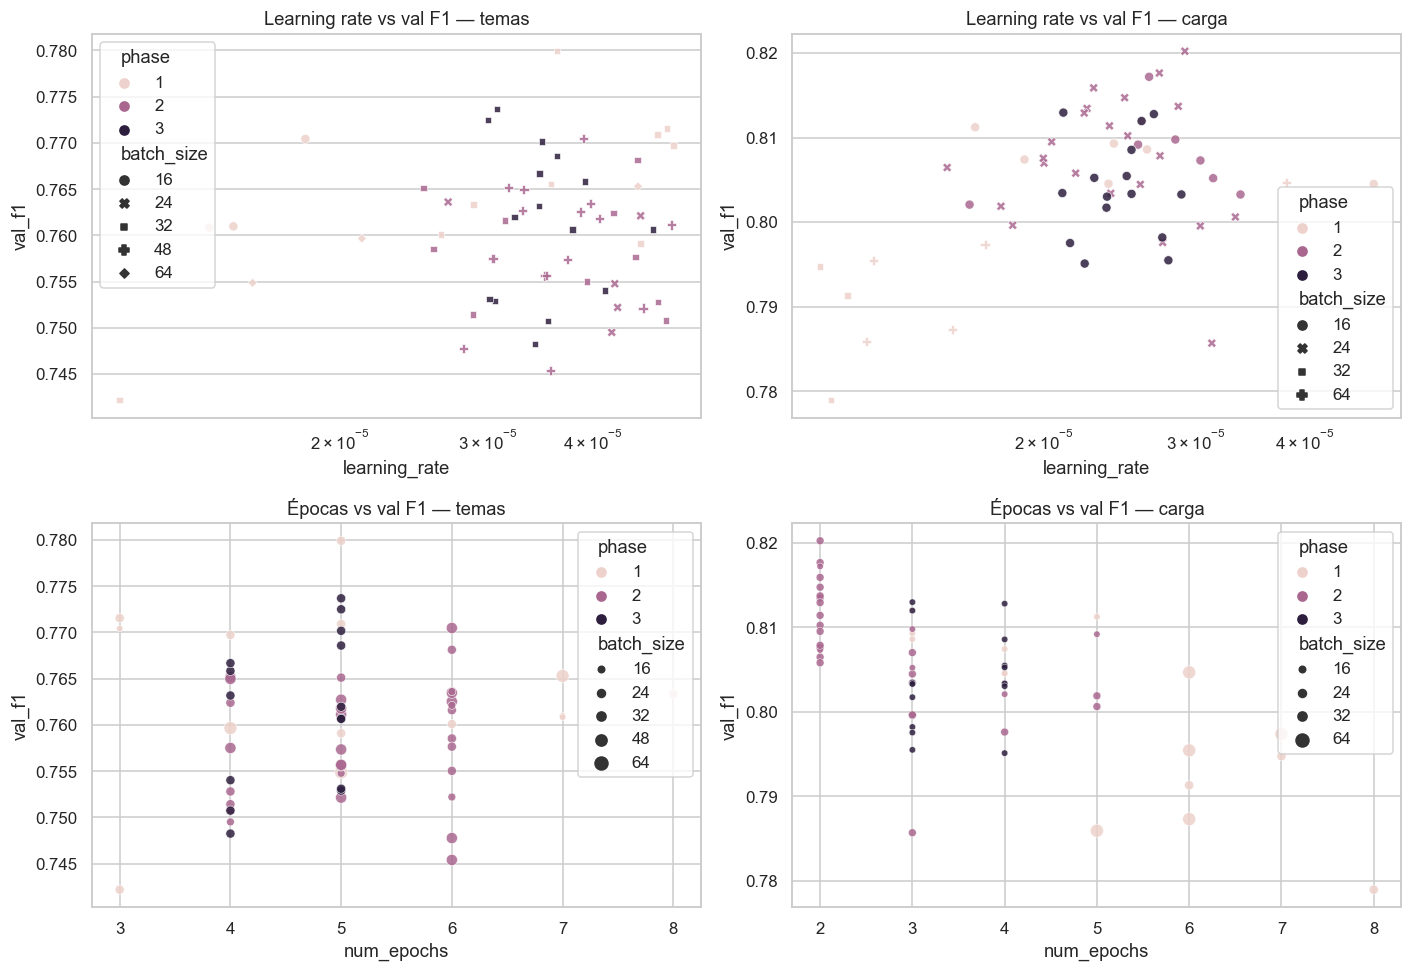

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, task in zip(axes[0], TASKS):
    subset = trials[trials["task"] == task]
    sns.scatterplot(
        data=subset,
        x="learning_rate",
        y="val_f1",
        hue="phase",
        style="batch_size",
        ax=ax,
        alpha=0.85,
    )
    ax.set_xscale("log")
    ax.set_title(f"Learning rate vs val F1 — {task}")

for ax, task in zip(axes[1], TASKS):
    subset = trials[trials["task"] == task]
    sns.scatterplot(
        data=subset,
        x="num_epochs",
        y="val_f1",
        hue="phase",
        size="batch_size",
        ax=ax,
        alpha=0.85,
    )
    ax.set_title(f"Épocas vs val F1 — {task}")

plt.tight_layout()
plt.show()


In [5]:
# Métricas por clase del modelo final (metrics.json)
from sklearn.metrics import classification_report

rows = []
for task in TASKS:
    best = bests[bests["task"] == task].sort_values("test_f1", ascending=False).iloc[0]
    metrics_path = Path(best["model_dir"]) / "metrics.json"
    if not metrics_path.exists():
        print("Missing", metrics_path)
        continue
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    report = metrics.get("classification_report", {})
    for label, scores in report.items():
        if label in ("accuracy", "macro avg", "weighted avg"):
            continue
        rows.append(
            {
                "task": task,
                "label": label,
                "f1": scores["f1-score"],
                "precision": scores["precision"],
                "recall": scores["recall"],
                "support": scores["support"],
            }
        )

per_class = pd.DataFrame(rows)
per_class.sort_values(["task", "f1"])


,task,label,f1,precision,recall,support
12,carga,alta,0.726688,0.869231,0.624309,181.0
11,carga,media,0.804239,0.789704,0.819318,880.0
10,carga,baja,0.818425,0.808707,0.828378,740.0
9,temas,sociedad,0.585683,0.537849,0.642857,210.0
5,temas,cultura,0.669951,0.653846,0.686869,99.0
8,temas,internacional,0.687500,0.707602,0.668508,181.0
3,temas,salud,0.688172,0.761905,0.627451,51.0
0,temas,politica,0.712121,0.770492,0.661972,284.0
2,temas,economia,0.750000,0.732899,0.767918,293.0
6,temas,tecnologia,0.761062,0.811321,0.716667,60.0


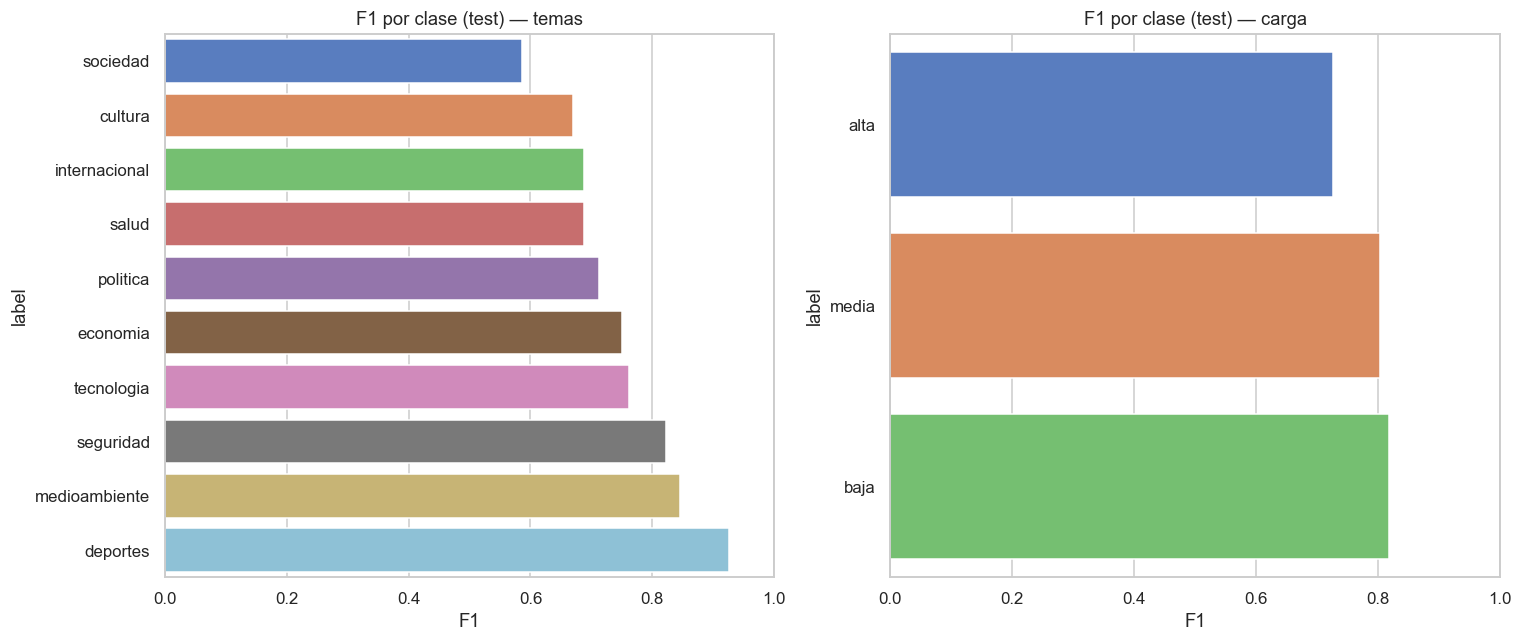

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

for ax, task in zip(axes, TASKS):
    subset = per_class[per_class["task"] == task].sort_values("f1")
    sns.barplot(data=subset, x="f1", y="label", ax=ax, orient="h")
    ax.set_xlim(0, 1)
    ax.set_title(f"F1 por clase (test) — {task}")
    ax.set_xlabel("F1")

plt.tight_layout()
plt.show()


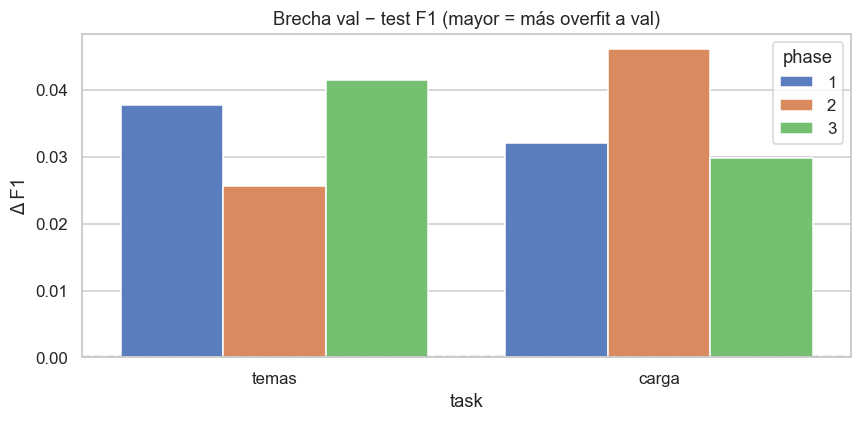

,task,phase,trial,val_f1,test_f1,gap,learning_rate,batch_size,num_epochs
0,temas,1,14,0.779919,0.742096,0.037823,0.000036,32,5
1,temas,2,17,0.770486,0.744776,0.025710,0.000039,48,6
2,temas,3,1,0.773695,0.732175,0.041520,0.000031,32,5
3,carga,1,10,0.811953,0.779883,0.032070,0.000026,16,3
4,carga,2,16,0.820213,0.774104,0.046109,0.000029,24,2
5,carga,3,2,0.812952,0.783117,0.029835,0.000021,16,3


In [7]:
# Gap val-test del mejor modelo por fase (overfitting proxy)
bests["gap"] = bests["val_f1"] - bests["test_f1"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=bests, x="task", y="gap", hue="phase", ax=ax)
ax.axhline(0, ls="--", c="gray")
ax.set_title("Brecha val − test F1 (mayor = más overfit a val)")
ax.set_ylabel("Δ F1")
plt.tight_layout()
plt.show()

bests[["task", "phase", "trial", "val_f1", "test_f1", "gap", "learning_rate", "batch_size", "num_epochs"]]
